In [4]:
import numpy as np
import pandas as pd

In [118]:
df = pd.read_csv('athlete_events_through_2026.csv')
region_df = pd.read_csv('noc_regions.csv')

In [6]:
df.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
315089,144281,Ethan Cepuran,M,25.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN
315090,149495,Motonaga Arito,M,23.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN
315091,149498,Timothy Loubineaud,M,29.0,183.0,75.0,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN
315092,149508,Sigurd Holbø Dyrset,M,21.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN
315093,149510,Germain Deschamps,M,23.0,179.0,70.0,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN


In [7]:
df = df[df['Season'] == 'Summer']

In [121]:
df = df.merge(region_df, on = 'NOC', how = 'left')

In [9]:
df[df['region'] == 'Pakistan']

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
37044,16951,Muhammad Sharif Butt,M,22.0,NaN,NaN,Pakistan,PAK,1948 Summer,1948,Summer,London,Athletics,Athletics Men's 100 metres,NaN,Pakistan,NaN
37111,59159,Mazar Ul-Haq Khan,M,NaN,NaN,NaN,Pakistan,PAK,1948 Summer,1948,Summer,London,Athletics,Athletics Men's 110 metres Hurdles,NaN,Pakistan,NaN
37133,16951,Muhammad Sharif Butt,M,22.0,NaN,NaN,Pakistan,PAK,1948 Summer,1948,Summer,London,Athletics,Athletics Men's 200 metres,NaN,Pakistan,NaN
37389,59163,Mohsin Nazar Khan,M,20.0,NaN,NaN,Pakistan,PAK,1948 Summer,1948,Summer,London,Athletics,Athletics Men's 400 metres Hurdles,NaN,Pakistan,NaN
37548,59177,Nazar Muhammad Khan Malik,M,NaN,NaN,NaN,Pakistan,PAK,1948 Summer,1948,Summer,London,Athletics,Athletics Men's Discus Throw,NaN,Pakistan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246432,144775,Kishmala Talat,F,22.0,NaN,NaN,PAK,PAK,2024 Summer,2024,Summer,Paris,Shooting,"Shooting Air Pistol (10 metres), Women",NaN,Pakistan,NaN
246622,8428,Ghulam Mustafa Bashir,M,37.0,180.0,74.0,PAK,PAK,2024 Summer,2024,Summer,Paris,Shooting,"Shooting Rapid-Fire Pistol (25 metres), Men",NaN,Pakistan,NaN
246842,144775,Kishmala Talat,F,22.0,NaN,NaN,PAK,PAK,2024 Summer,2024,Summer,Paris,Shooting,"Shooting Sporting Pistol (25 metres), Women",NaN,Pakistan,NaN
247733,146593,Muhammad Ahmed Durrani,M,18.0,NaN,NaN,PAK,PAK,2024 Summer,2024,Summer,Paris,Swimming,"Swimming 200 metres Freestyle, Men",NaN,Pakistan,NaN


In [10]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN
4,41160,Dimitrios P. Golemis,M,21.0,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN


In [11]:
# Country Counts
df['region'].unique().shape

(206,)

In [12]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9193
Height     67330
Weight     71428
Team        6507
NOC         6507
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     213637
region      7413
notes     246214
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(1385)

In [14]:
df.drop_duplicates(inplace = True)

In [15]:
df = pd.concat([df, pd.get_dummies(df['Medal'], dtype=int)], axis=1 )
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN,0,0,1
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN,0,1,0
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN,0,0,0
4,41160,Dimitrios P. Golemis,M,21.0,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250742,148322,Mamadassa Sylla,M,31.0,NaN,NaN,FRA,FRA,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,France,NaN,0,0,0
250743,148323,Andrés Montaño,M,34.0,166.0,59.0,ECU,ECU,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Ecuador,NaN,0,0,0
250744,148324,Néstor Almanza,M,21.0,NaN,NaN,CHI,CHI,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Chile,NaN,0,0,0
250745,148325,Kyotaro Sogabe,M,23.0,NaN,NaN,JPN,JPN,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Japan,NaN,0,0,0


In [16]:
df.groupby('NOC').sum()[['Gold', 'Bronze', 'Silver']].sort_values('Gold', ascending = False)

,Gold,Bronze,Silver
NOC,,,
USA,2630,1320,1449
URS,832,596,635
GBR,656,672,757
GER,606,683,587
FRA,554,621,686
...,...,...,...
WIF,0,5,0
YEM,0,0,0
YAR,0,0,0


In [17]:
medal_tally = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

In [18]:
medal_tally = medal_tally.groupby('region').sum()[['Gold',  'Silver', 'Bronze']].sort_values('Gold', ascending = False)

In [19]:
medal_tally

,Gold,Silver,Bronze
region,,,
USA,1098,866,772
Russia,592,498,487
Germany,458,472,504
UK,299,345,334
China,281,209,192
...,...,...,...
Vanuatu,0,0,0
"Virgin Islands, British",0,0,0
"Virgin Islands, US",0,1,0


In [20]:
medal_tally['Total'] = medal_tally['Gold'] + medal_tally['Bronze'] + medal_tally['Silver']

In [21]:
medal_tally['Rank'] = range(1, len(medal_tally) + 1)

In [22]:
medal_tally = medal_tally.reset_index()


In [23]:
medal_tally = medal_tally[
    ['Rank', 'region', 'Gold', 'Silver', 'Bronze', 'Total']
]

In [24]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN,0,0,1
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN,0,1,0
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN,0,0,0
4,41160,Dimitrios P. Golemis,M,21.0,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250742,148322,Mamadassa Sylla,M,31.0,NaN,NaN,FRA,FRA,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,France,NaN,0,0,0
250743,148323,Andrés Montaño,M,34.0,166.0,59.0,ECU,ECU,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Ecuador,NaN,0,0,0
250744,148324,Néstor Almanza,M,21.0,NaN,NaN,CHI,CHI,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Chile,NaN,0,0,0
250745,148325,Kyotaro Sogabe,M,23.0,NaN,NaN,JPN,JPN,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Japan,NaN,0,0,0


In [25]:
years = df['Year'].unique().tolist()
years.sort()
years.insert(0, 'Overall')
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016,
 2020,
 2024]

In [26]:
countries = np.unique(df['region'].dropna().values).tolist()
countries.sort()
countries.insert(0, 'Overall')
countries

['Overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [27]:
def fetch_medal_tally(df, years, countries):
    medal_df = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])
    
    flag = 0
    
    if years == 'Overall' and countries == 'Overall':
        temp_df = medal_df
    elif years == 'Overall' and countries != 'Overall':
        flag = 1
        temp_df = medal_df[medal_df['region'] == countries]
    elif years != 'Overall' and countries == 'Overall':
        temp_df = medal_df[medal_df['Year'] == int(years)]
    elif years != 'Overall' and countries != 'Overall':
        temp_df = medal_df[(medal_df['Year'] == int(years)) & (medal_df['region'] == countries)]
    
    if flag == 1:    
        x = temp_df.groupby('Year').sum()[['Gold', 'Bronze', 'Silver']].sort_values('Year')
    else:
        x = temp_df.groupby('region').sum()[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False)
    
    x['Total'] = x['Gold'] + x['Bronze'] + x['Silver']
    x['region'] = countries
    
    x = x.reset_index()
    x = x[['Year', 'region', 'Gold', 'Silver', 'Bronze', 'Total']]
    
    print(x)

In [28]:
medal_df = df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

In [29]:
medal_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN,0,0,1
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN,0,1,0
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN,0,0,0
6,68911,Albin Georges Lermusiaux,M,21.0,NaN,NaN,France,FRA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Bronze,France,NaN,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250742,148322,Mamadassa Sylla,M,31.0,NaN,NaN,FRA,FRA,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,France,NaN,0,0,0
250743,148323,Andrés Montaño,M,34.0,166.0,59.0,ECU,ECU,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Ecuador,NaN,0,0,0
250744,148324,Néstor Almanza,M,21.0,NaN,NaN,CHI,CHI,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Chile,NaN,0,0,0
250745,148325,Kyotaro Sogabe,M,23.0,NaN,NaN,JPN,JPN,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Japan,NaN,0,0,0


# Overall Analysis

1. Number of Editions
2. Number of Cities
3. Number of Events, Sports
4. Number of Athleats
5. Participating Nations
   

In [30]:
df['Year'].unique().shape[0]

31

In [31]:
cities = df['City'].unique().shape[0]

In [32]:
sports = df['Sport'].unique().shape[0]

In [33]:
events = df['Event'].unique().shape[0]

In [34]:
athlets = df['Name'].unique().shape[0]

In [35]:
regions = df['region'].unique()
regions

array(['USA', 'Greece', 'Australia', 'Germany', 'France', 'UK', 'Denmark',
       'Sweden', 'Hungary', 'Austria', 'Switzerland', 'Italy', 'Belgium',
       'Netherlands', 'Czech Republic', 'India', 'Brazil', 'Canada',
       'Norway', 'Luxembourg', 'Spain', 'Russia', 'Haiti', 'Peru',
       'Argentina', 'Cuba', 'Iran', 'Mexico', 'Romania', 'Colombia',
       'New Zealand', 'South Africa', 'Turkey', 'Finland', 'Egypt',
       'Iceland', nan, 'Poland', 'Chile', 'Serbia', 'Japan', 'Portugal',
       'Estonia', 'Monaco', 'Uruguay', 'Ireland', 'Bulgaria', 'Latvia',
       'Ecuador', 'Philippines', 'Lithuania', 'Zimbabwe', 'Panama',
       'Malta', 'Guatemala', 'El Salvador', 'Venezuela', 'China',
       'Boliva', 'Liechtenstein', 'Afghanistan', 'Costa Rica', 'Bermuda',
       'South Korea', 'Trinidad', 'Pakistan', 'Jamaica', 'Myanmar',
       'Iraq', 'Guyana', 'Puerto Rico', 'Sri Lanka', 'Lebanon', 'Syria',
       'Thailand', 'Vietnam', 'Ghana', 'Nigeria', 'Israel', 'Indonesia',
       'Cur

In [44]:
nations_over_time = df.drop_duplicates(['Year', 'region'])['Year'].value_counts().reset_index().sort_values('Year')

In [45]:
nations_over_time.rename(columns={'Year' : 'Edition', 'count' : 'No of Countries'}, inplace = True)

In [46]:
import plotly.express as px

In [51]:
fig = px.line(nations_over_time, x = 'Edition', y = 'No of Countries')
fig.show()

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 249362 entries, 0 to 250746
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      249362 non-null  int64  
 1   Name    249362 non-null  object 
 2   Sex     249362 non-null  object 
 3   Age     240328 non-null  float64
 4   Height  183389 non-null  float64
 5   Weight  179282 non-null  float64
 6   Team    242855 non-null  object 
 7   NOC     242855 non-null  object 
 8   Games   249362 non-null  object 
 9   Year    249362 non-null  int64  
 10  Season  249362 non-null  object 
 11  City    249362 non-null  object 
 12  Sport   249362 non-null  object 
 13  Event   249362 non-null  object 
 14  Medal   37099 non-null   object 
 15  region  241949 non-null  object 
 16  notes   4529 non-null    object 
 17  Bronze  249362 non-null  int64  
 18  Gold    249362 non-null  int64  
 19  Silver  249362 non-null  int64  
dtypes: float64(3), int64(5), object(12)
memory usage: 40.

In [53]:
df.drop_duplicates(['Year', 'Event'])['Year'].value_counts().reset_index().sort_values('Year')

,Year,count
30,1896,43
28,1900,90
27,1904,95
29,1906,74
25,1908,109
26,1912,107
16,1920,158
22,1924,131
24,1928,122
23,1932,131


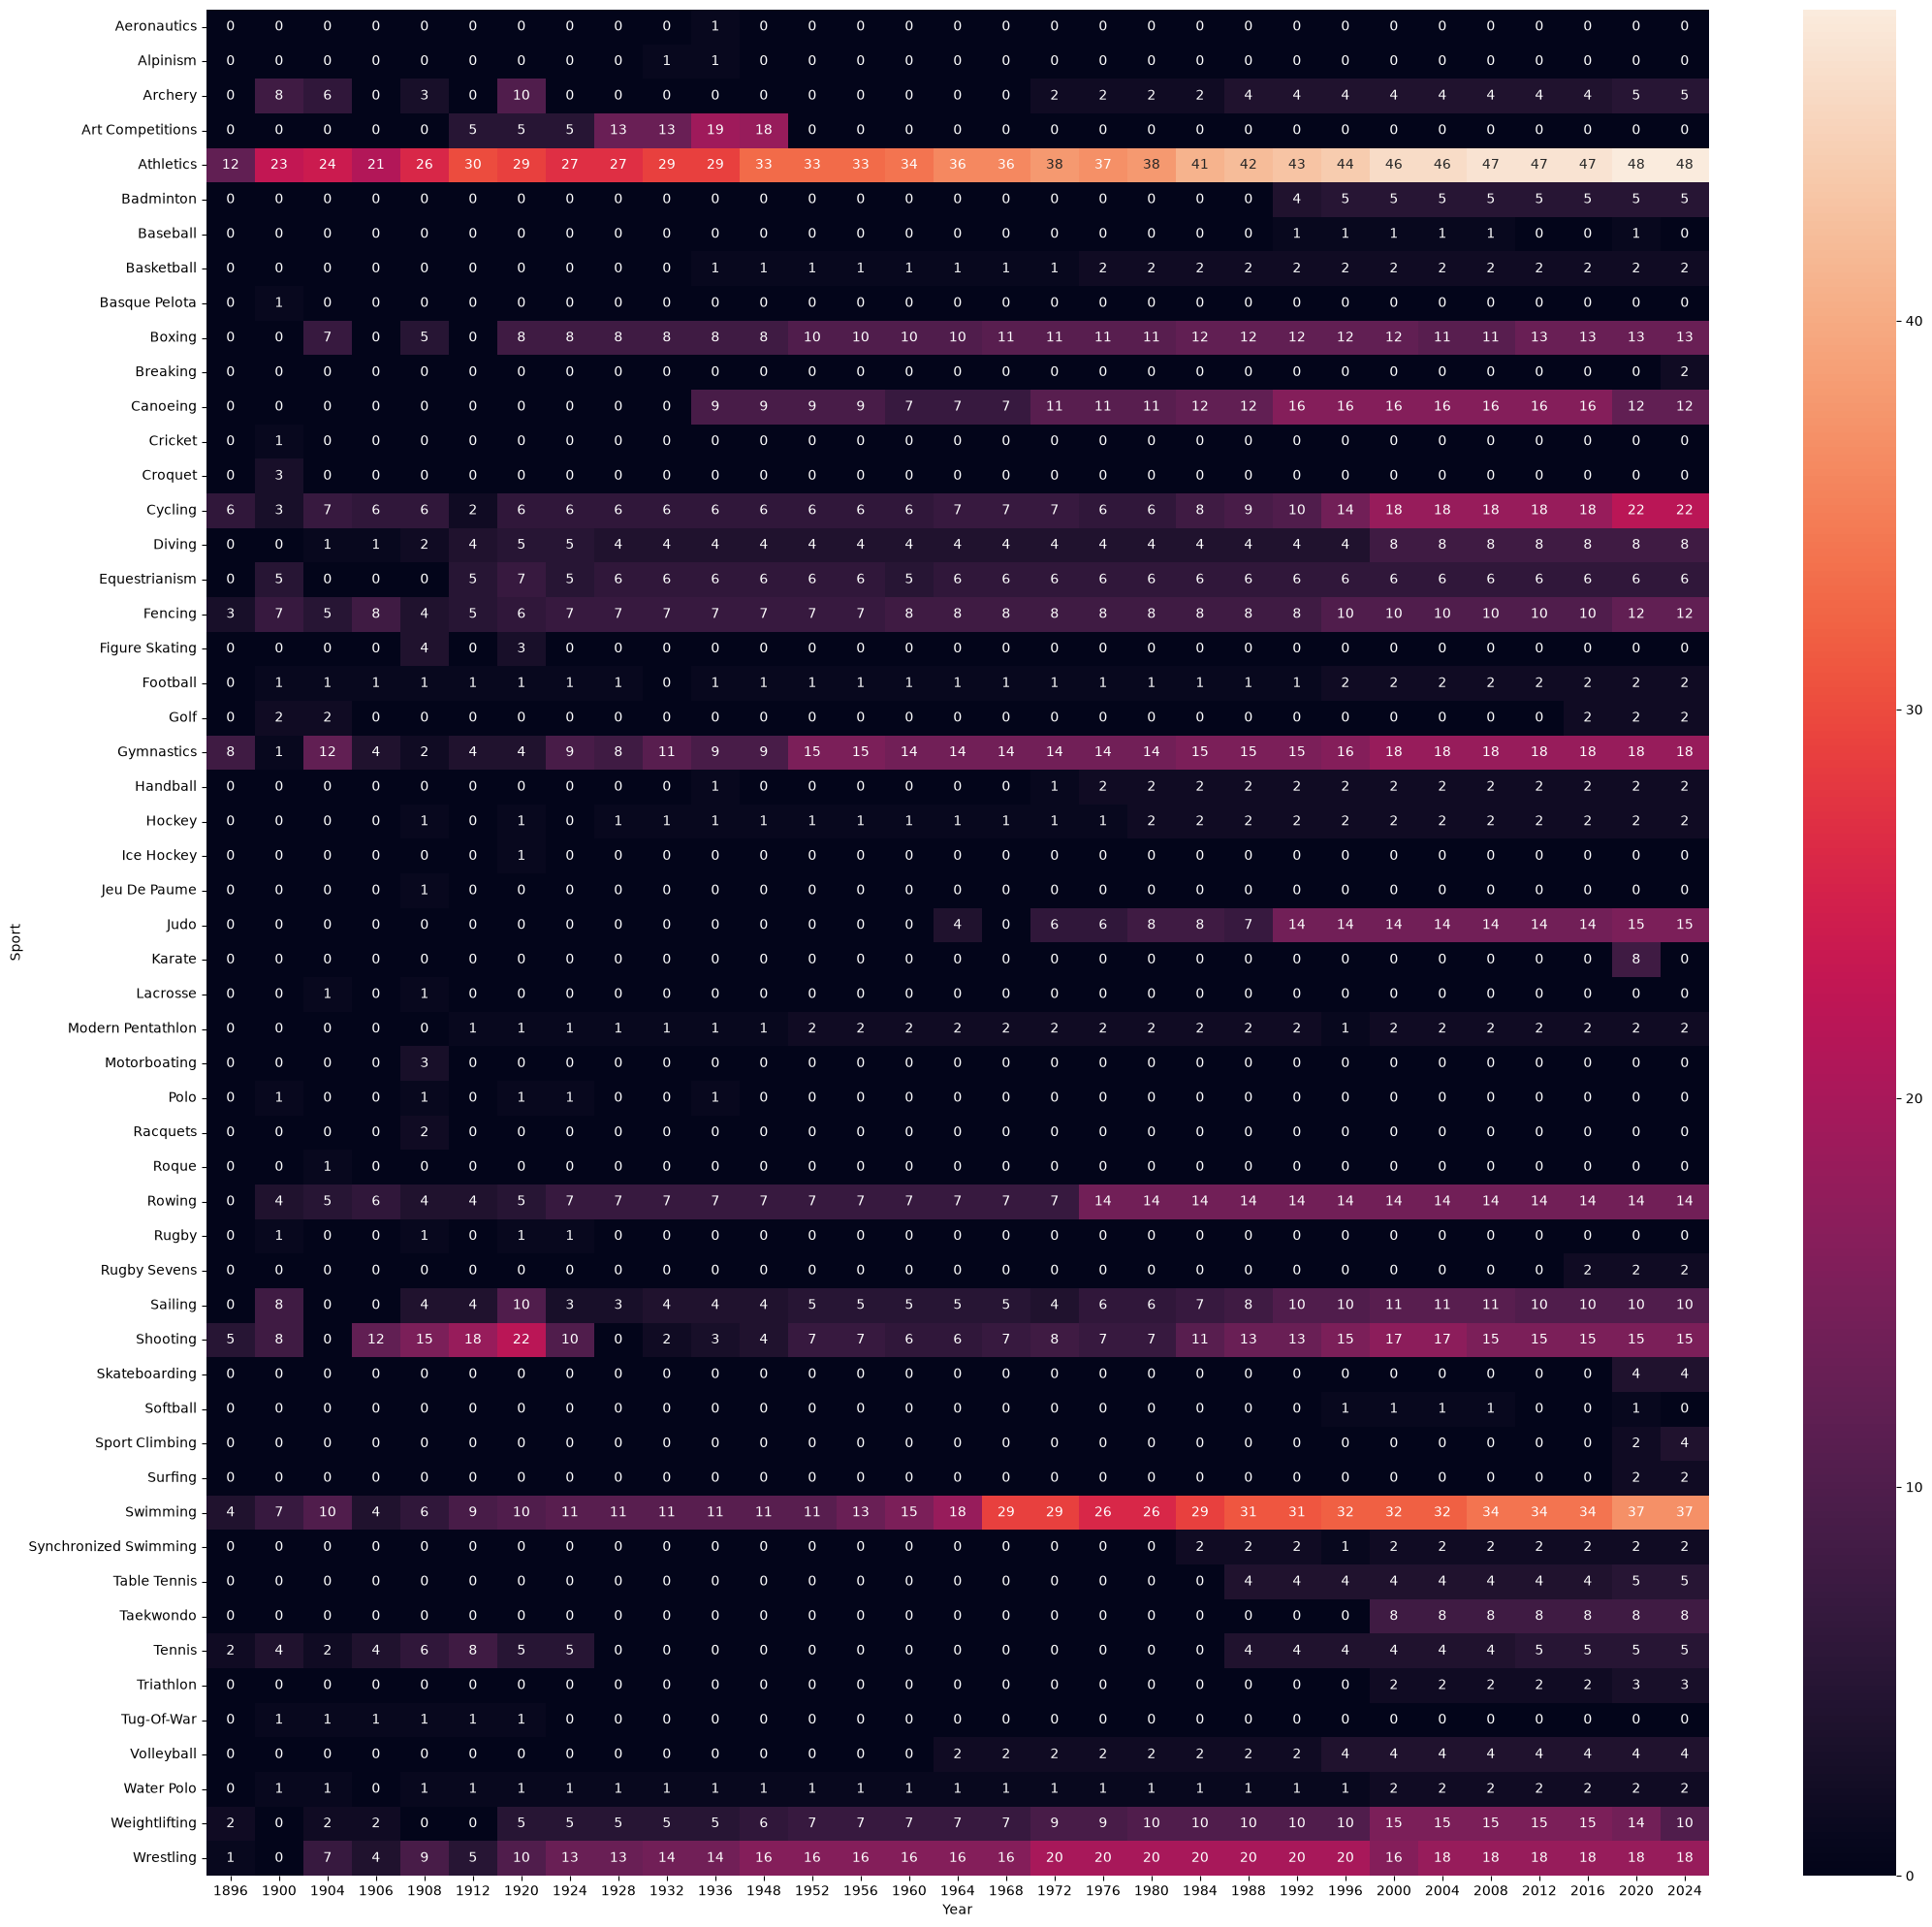

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(25, 25))
sns.heatmap(
    df.pivot_table(index='Sport', columns='Year', values='Event', aggfunc='nunique').fillna(0).astype('int'),
    annot=True,
    fmt='d'
)
plt.show()

In [62]:
x = df.drop_duplicates(['Year', 'Sport', 'Event'])

In [67]:
pivot_table = x.pivot_table(index = 'Sport', columns= 'Year', values = 'Event', aggfunc= 'count').fillna(0).astype('int')

<Axes: xlabel='Year', ylabel='Sport'>

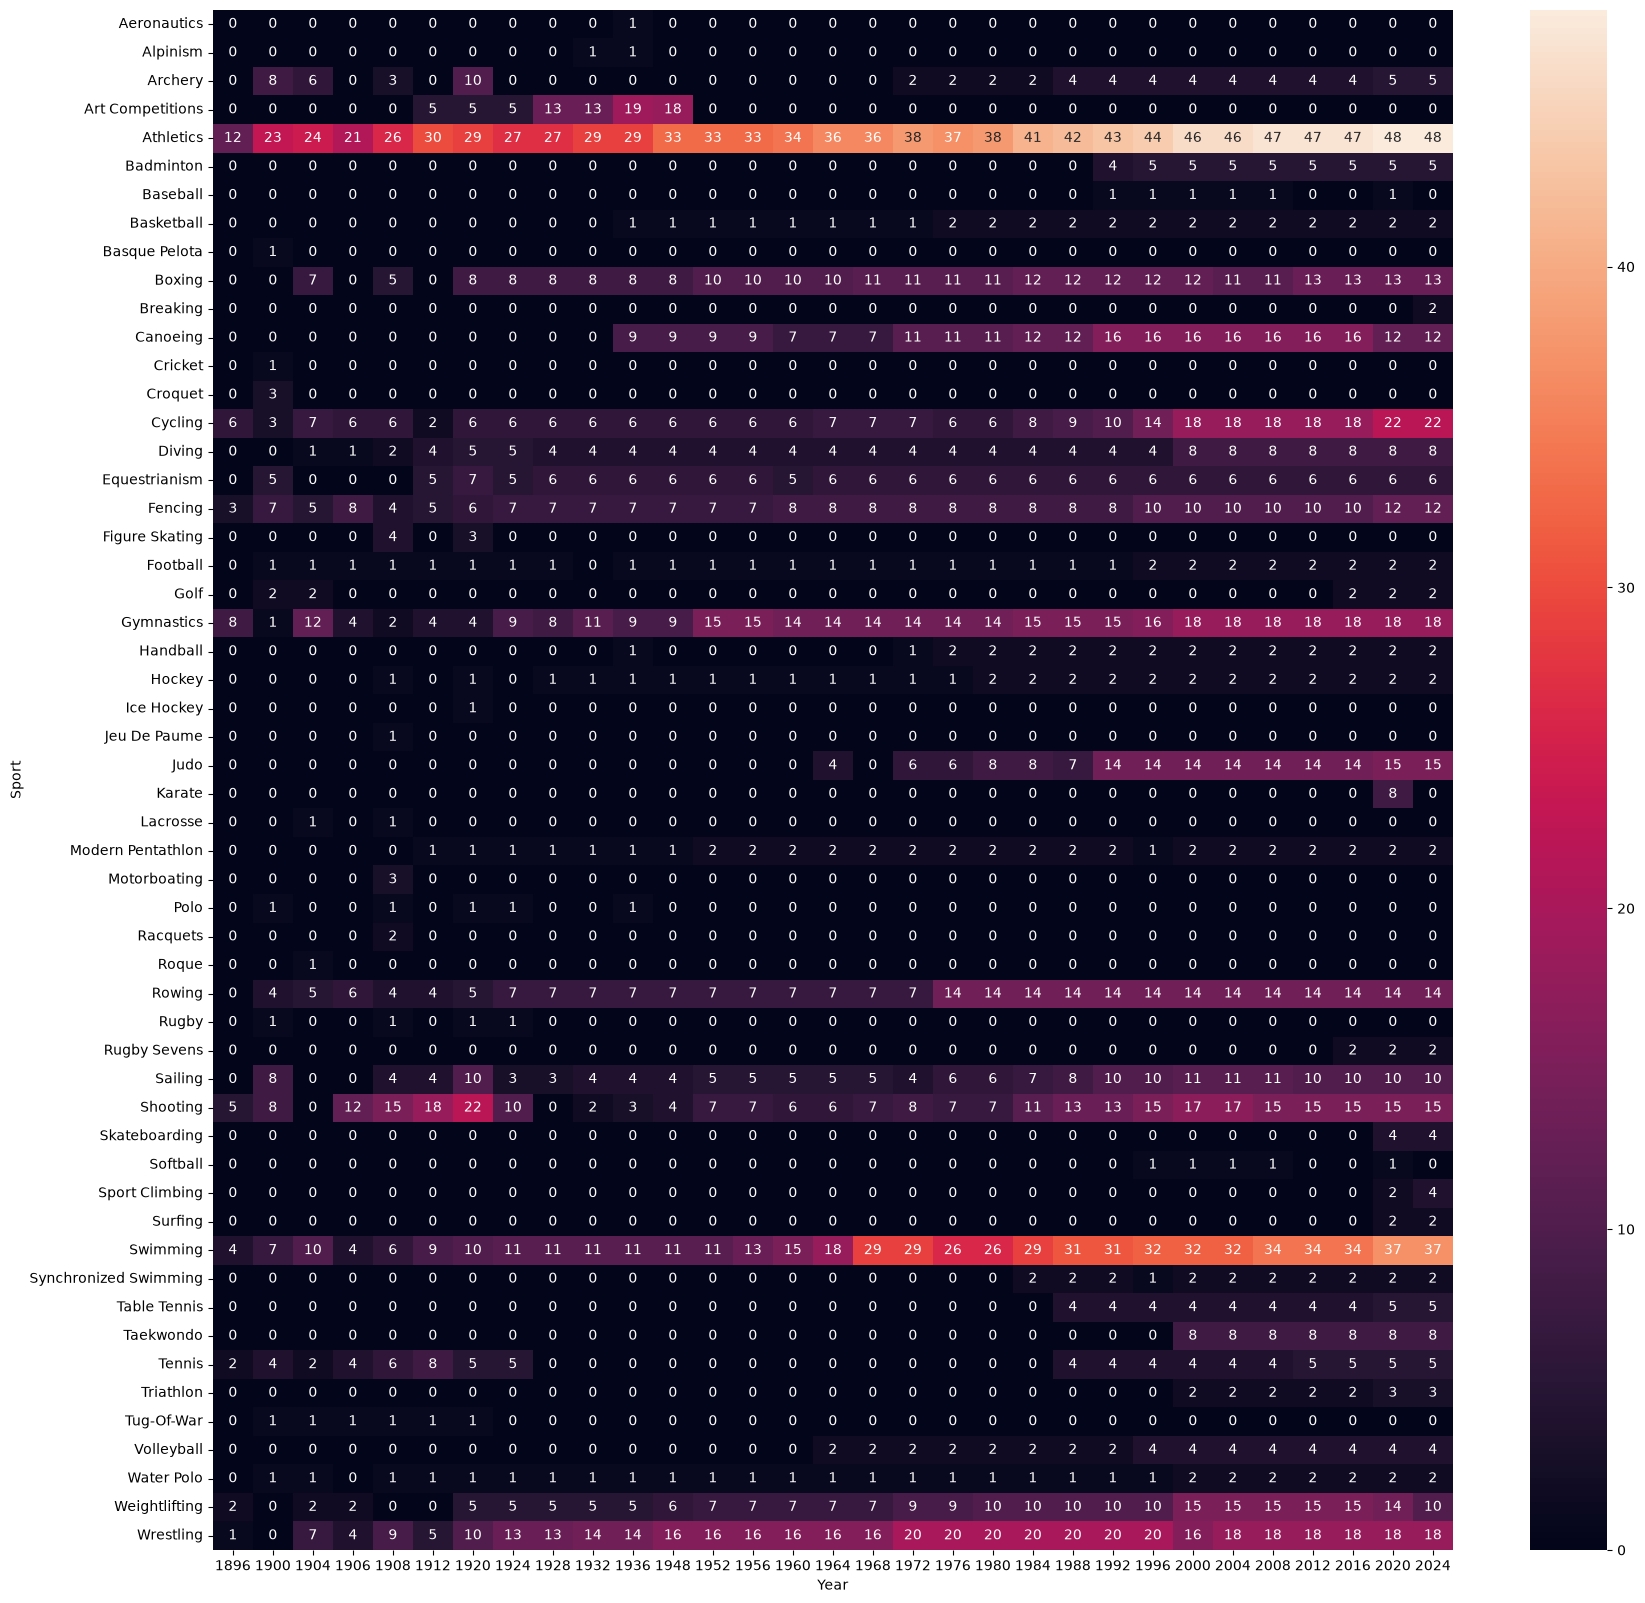

In [71]:
plt.figure(figsize= (20, 20))
sns.heatmap(pivot_table, annot= True)

In [85]:
df = df.drop_duplicates(['Name', 'Sport', 'Event'])

In [94]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN,0,0,1
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN,0,1,0
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN,0,0,0
4,41160,Dimitrios P. Golemis,M,21.0,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250742,148322,Mamadassa Sylla,M,31.0,NaN,NaN,FRA,FRA,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,France,NaN,0,0,0
250743,148323,Andrés Montaño,M,34.0,166.0,59.0,ECU,ECU,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Ecuador,NaN,0,0,0
250744,148324,Néstor Almanza,M,21.0,NaN,NaN,CHI,CHI,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Chile,NaN,0,0,0
250745,148325,Kyotaro Sogabe,M,23.0,NaN,NaN,JPN,JPN,2024 Summer,2024,Summer,Paris,Wrestling,"Wrestling Welterweight, Greco-Roman (≤67 kg), Men",NaN,Japan,NaN,0,0,0


In [125]:
most(df, 'Gymnastics')

,Name,Medals,Sport,Region
0,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
19,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
43,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
67,Takashi Ono,13,Gymnastics,Japan
100,Sawao Kato,12,Gymnastics,Japan
...,...,...,...,...
9024,Zhou Yaqin,1,Gymnastics,China
9027,Manila Esposito,1,Gymnastics,Italy
9032,Alice D'Amato,1,Gymnastics,Italy
9042,Liu Lingling,1,Gymnastics,China


In [124]:
def most(df, sport):
    temp_df = df.dropna(subset = ["Medal"])
    
    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]
    
    x = temp_df['Name'].value_counts().reset_index().merge(df, left_on = 'Name', right_on = 'Name', how = 'left' )[['Name', 'count', 'Sport', 'region']].drop_duplicates('Name')
    x.rename(columns= {'count': 'Medals', 'region': 'Region'}, inplace= True)
    return x

In [108]:
def most_successful(df, sport):
    temp_df = df.dropna(subset = ['Medal'])
    
    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]
    medal_count = temp_df['Name'].value_counts()    
    return temp_df['Name'].value_counts().reset_index().merge(df, left_on = 'Name', right_on = 'Name', how = 'left')[['Name', 'count', 'Sport', 'region']].drop_duplicates('Name')

In [109]:
most_successful(df, 'Overall')

,Name,count,Sport,region
0,Carl Townsend Osburn,11,Shooting,USA
15,Gerard Theodor Hubert Van Innis,10,Archery,Belgium
26,Zoltn Imre dn von Halmay,8,Swimming,Hungary
34,Gustaf Vilhelm Carlberg,8,Shooting,Sweden
56,Mikhail Yakovlevich Voronin,7,Gymnastics,Russia
...,...,...,...,...
40856,Georgios Saranti Papasideris,1,Athletics,Greece
40859,Ioannis Persakis,1,Athletics,Greece
40860,Pierre Alexandre Tuffri,1,Athletics,France
40864,Gaston Jules Louis Antoine Alibert,1,Fencing,France


In [146]:
df = df.drop_duplicates(['Name', 'Sport', 'Event'])

def most_successful(df, sport):
    temp_df = df.dropna(subset=['Medal'])
    
    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]
        
    medal_count = temp_df['Name'].value_counts().reset_index()
    
    return medal_count.merge(
        df,
        left_on='Name',
        right_on='Name',
        how='left'
    )

most_successful(df, 'Overall')

,Name,count,ID,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,Carl Townsend Osburn,11,89706,M,28.0,180.0,NaN,United States,USA,1912 Summer,1912,Summer,Stockholm,Shooting,"Shooting Men's Free Rifle, Three Positions, 30...",NaN,USA,NaN
1,Carl Townsend Osburn,11,89706,M,28.0,180.0,NaN,United States,USA,1912 Summer,1912,Summer,Stockholm,Shooting,"Shooting Men's Military Rifle, 200, 400, 500 a...",Gold,USA,NaN
2,Carl Townsend Osburn,11,89706,M,28.0,180.0,NaN,United States,USA,1912 Summer,1912,Summer,Stockholm,Shooting,"Shooting Men's Military Rifle, Any Position, 6...",Silver,USA,NaN
3,Carl Townsend Osburn,11,89706,M,28.0,180.0,NaN,United States,USA,1912 Summer,1912,Summer,Stockholm,Shooting,"Shooting Men's Military Rifle, Three Positions...",Silver,USA,NaN
4,Carl Townsend Osburn,11,89706,M,28.0,180.0,NaN,United States,USA,1912 Summer,1912,Summer,Stockholm,Shooting,"Shooting Men's Small-Bore Rifle, Any Position,...",NaN,USA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48536,Georgios Saranti Papasideris,1,91250,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,Athletics Men's Discus Throw,NaN,Greece,NaN
48537,Georgios Saranti Papasideris,1,91250,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,Athletics Men's Shot Put,Bronze,Greece,NaN
48538,Georgios Saranti Papasideris,1,91250,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Weightlifting,"Weightlifting Men's Unlimited, Two Hands",NaN,Greece,NaN
48539,"Thomas Pelham ""Tom"" Curtis",1,24423,M,23.0,176.0,66.0,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,Athletics Men's 100 metres,NaN,USA,NaN


# Country wise Analysis

- Country wise medal tally per year (line Plot)
- What countries are good at heatmap
- Most Successful Athletes (Top 10)


In [126]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN
4,41160,Dimitrios P. Golemis,M,21.0,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315089,144281,Ethan Cepuran,M,25.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN
315090,149495,Motonaga Arito,M,23.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN
315091,149498,Timothy Loubineaud,M,29.0,183.0,75.0,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN
315092,149508,Sigurd Holbø Dyrset,M,21.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN


In [128]:
temp_df = df.dropna(subset = ['Medal'])

In [ ]:
temp_df = df.dropna(subset = ['Medal'])
temp_df.drop_duplicates(subset = ['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace = True)

C:\Users\Sulaiman\AppData\Local\Temp\ipykernel_10824\2977191434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.drop_duplicates(subset = ['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace = True)


In [139]:
new_df = temp_df[temp_df['region'] == 'USA']
final_df = new_df.groupby('Year').count()['Medal'].reset_index()
final_df

,Year,Medal
0,1896,19
1,1900,54
2,1904,231
3,1906,23
4,1908,46
5,1912,63
6,1920,95
7,1924,103
8,1928,62
9,1932,122


In [140]:
fig = px.line(final_df, x = 'Year', y = 'Medal')
fig.show()

In [141]:
temp_df = df.dropna(subset = ['Medal'])
temp_df.drop_duplicates(subset = ['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace = True)

C:\Users\Sulaiman\AppData\Local\Temp\ipykernel_10824\1626349555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df.drop_duplicates(subset = ['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace = True)


<Axes: xlabel='Year', ylabel='Sport'>

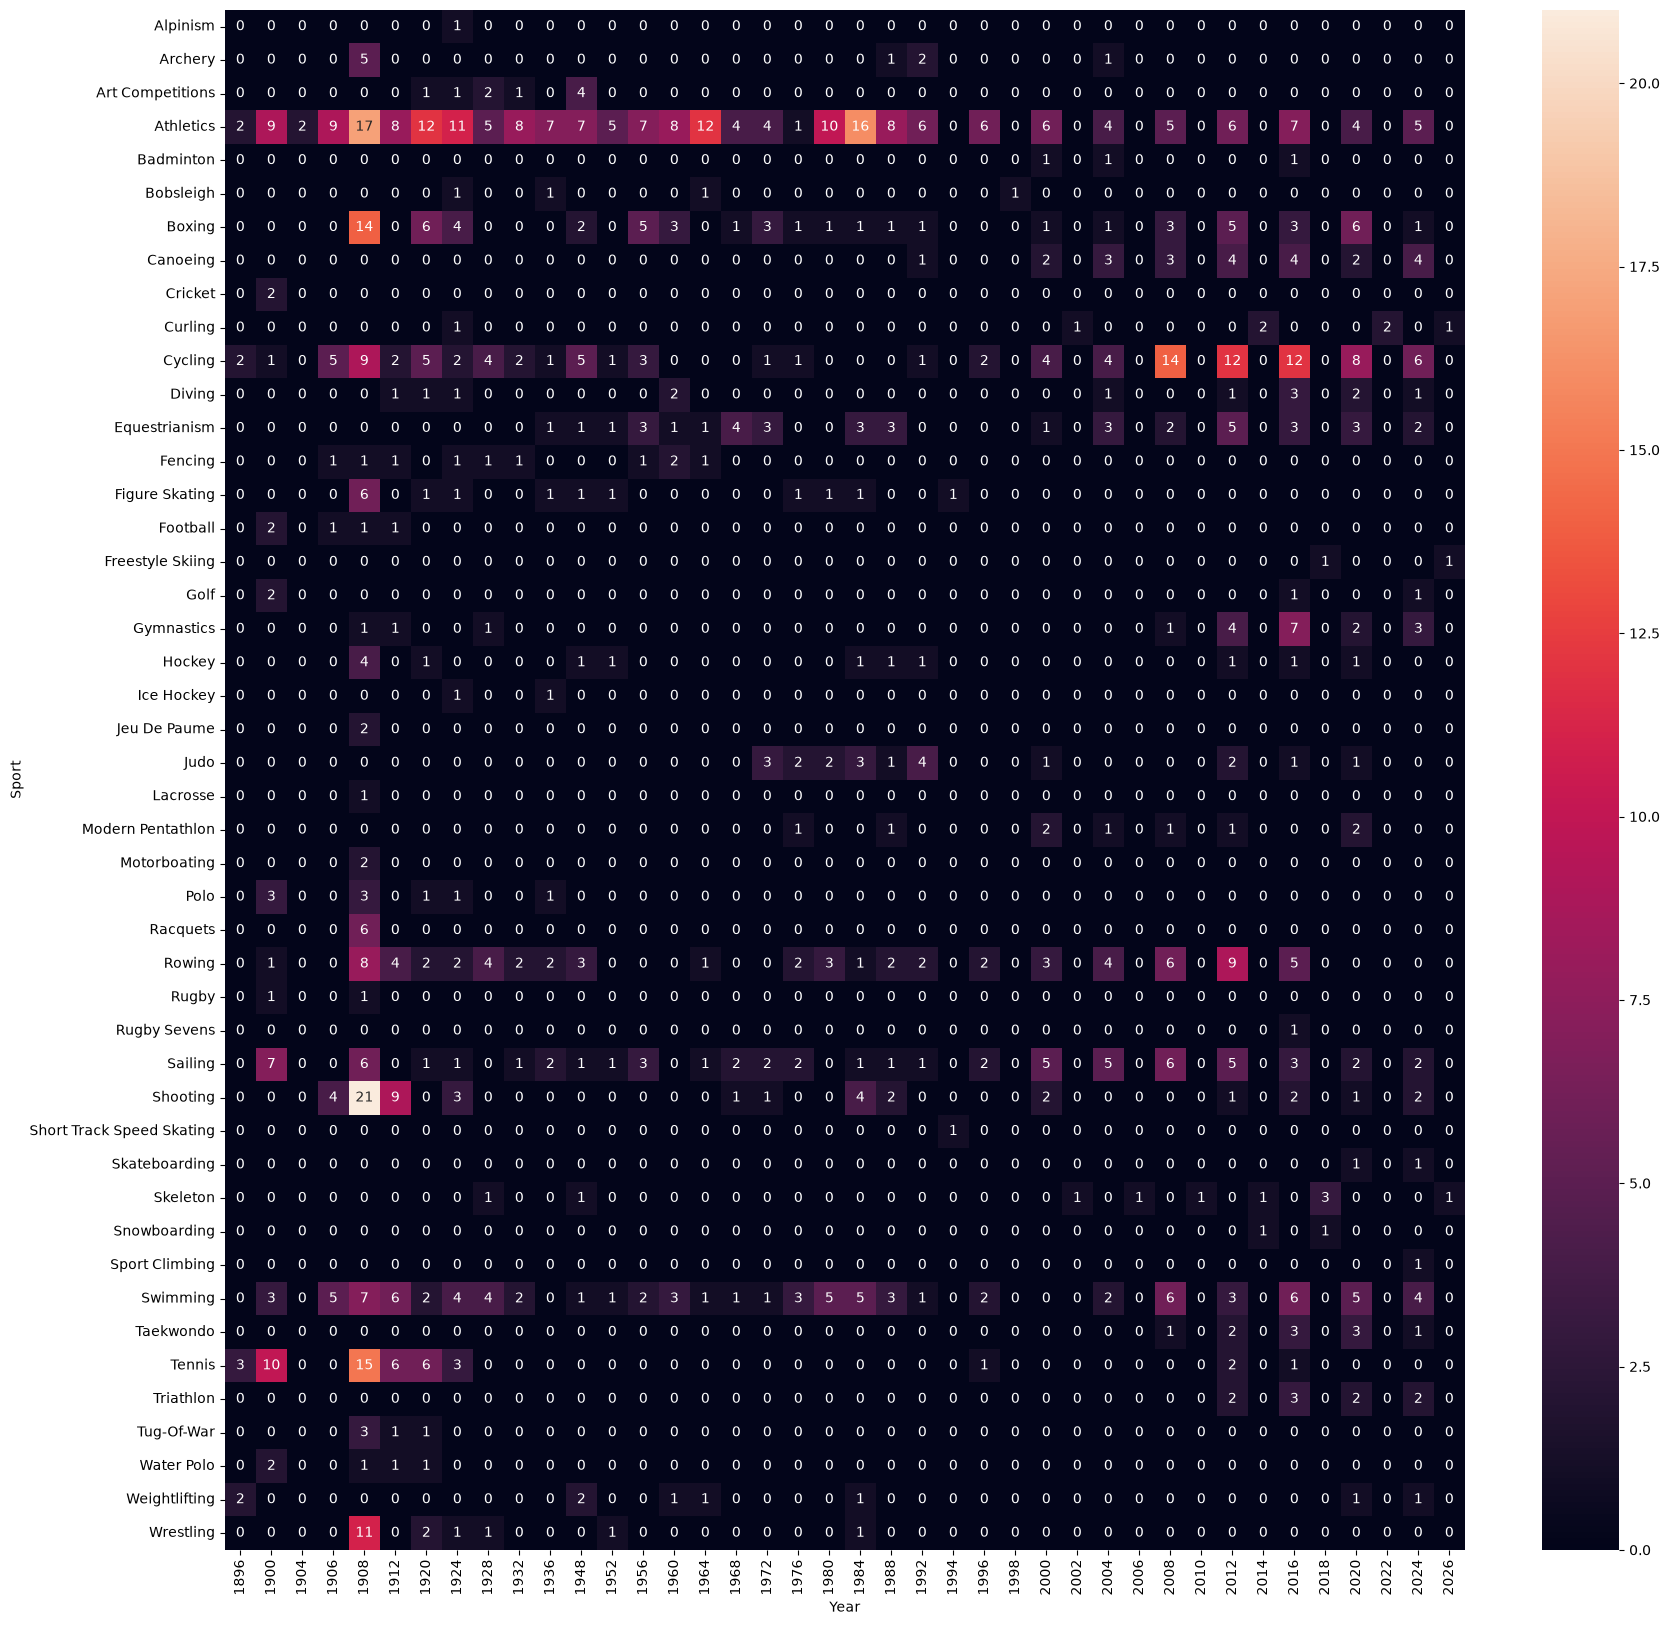

In [145]:
new_df = temp_df[temp_df['region'] == 'UK']
final_df = new_df.pivot_table(index = 'Sport', columns = 'Year', values = 'Medal', aggfunc= 'count').fillna(0)
plt.figure(figsize= (20, 20))
sns.heatmap(final_df, annot= True)


In [162]:
def most_successful(df, country):
    temp_df = df.dropna(subset = ['Medal'])
    
    temp_df = temp_df[temp_df['region'] == country]
        
    x = temp_df['Name'].value_counts().reset_index().merge(df, left_on = 'Name', right_on = 'Name', how = 'left')[['Name', 'count', 'Sport']].drop_duplicates('Name')
    x.rename(columns= {'Name':'Player Name', 'count': 'Medals Count', 'Sport': 'Sport Name'}, inplace = True)
    return x


In [163]:
most_successful(df, 'Pakistan')

,Player Name,Medals Count,Sport Name
0,Noor Alam,1,Hockey
1,Ahmed Naseer Bunda,1,Hockey
2,Munir Ahmed Dar,1,Hockey
3,Qazi Massarrat Hussain,1,Hockey
4,Zakir Hussain,1,Hockey
...,...,...,...
73,Muhammad Khalid,1,Hockey
74,Farhat Hassan Khan,1,Hockey
75,Mujahid Ali Rana,1,Hockey
76,Anjum Saeed,1,Hockey


In [ ]:
import plotly.express as px

In [ ]:
athlete_df = df.drop_duplicates(subset= ['Name', 'region'])
athlete_df['Age'].dropna()
athlete_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,12068,Arthur Charles Blake,M,24.0,NaN,NaN,United States,USA,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Silver,USA,NaN
1,35094,Angelos Fetsis,M,NaN,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN
2,35698,"Edwin Harold ""Teddy"" Flack",M,22.0,NaN,NaN,Australia,AUS,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,Australia,NaN
3,38123,Carl Galle,M,23.0,154.0,45.0,Germany,GER,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Germany,NaN
4,41160,Dimitrios P. Golemis,M,21.0,NaN,NaN,Greece,GRE,1896 Summer,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",NaN,Greece,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315087,137006,Jorrit Bergsma,M,40.0,188.0,73.0,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN
315090,149495,Motonaga Arito,M,23.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN
315091,149498,Timothy Loubineaud,M,29.0,183.0,75.0,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN
315092,149508,Sigurd Holbø Dyrset,M,21.0,NaN,NaN,NaN,NaN,2026 Winter,2026,Winter,Milano-Cortina,Speed Skating,"Speed Skating Team Pursuit (8 laps), Men",NaN,NaN,NaN


In [ ]:
athlete_df['Age'].dropna()

0         24.0
2         22.0
3         23.0
4         21.0
6         21.0
          ... 
315087    40.0
315090    23.0
315091    29.0
315092    21.0
315093    23.0
Name: Age, Length: 154704, dtype: float64

In [173]:
fig = px.histogram([athlete_df['Age'].dropna()], ['Age Distribution'])
fig.show()

In [174]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

fig = go.Figure()

# -----------------------------
# Bronze Medalists
# -----------------------------
bronze_age = athlete_df.loc[
    athlete_df['Medal'] == 'Bronze', 'Age'
].dropna()

kde = gaussian_kde(bronze_age)
x = np.linspace(bronze_age.min(), bronze_age.max(), 500)

fig.add_trace(
    go.Scatter(
        x=x,
        y=kde(x),
        mode='lines',
        name='Bronze Medalist'
    )
)

# -----------------------------
# Silver Medalists
# -----------------------------
silver_age = athlete_df.loc[
    athlete_df['Medal'] == 'Silver', 'Age'
].dropna()

kde = gaussian_kde(silver_age)
x = np.linspace(silver_age.min(), silver_age.max(), 500)

fig.add_trace(
    go.Scatter(
        x=x,
        y=kde(x),
        mode='lines',
        name='Silver Medalist'
    )
)

# -----------------------------
# Gold Medalists
# -----------------------------
gold_age = athlete_df.loc[
    athlete_df['Medal'] == 'Gold', 'Age'
].dropna()

kde = gaussian_kde(gold_age)
x = np.linspace(gold_age.min(), gold_age.max(), 500)

fig.add_trace(
    go.Scatter(
        x=x,
        y=kde(x),
        mode='lines',
        name='Gold Medalist'
    )
)

# -----------------------------
# All Athletes
# -----------------------------
all_age = athlete_df['Age'].dropna()

kde = gaussian_kde(all_age)
x = np.linspace(all_age.min(), all_age.max(), 500)

fig.add_trace(
    go.Scatter(
        x=x,
        y=kde(x),
        mode='lines',
        name='All Athlete'
    )
)

# -----------------------------
# Layout
# -----------------------------
fig.update_layout(
    title='Age Distribution by Medal',
    xaxis_title='Age',
    yaxis_title='Density',
    template='plotly_white',
    legend_title_text=''
)

fig.show()

In [ ]:
famous_sports = df['Sport'].unique()
x = []
name = []

for sport in famous_sports:
    temp_df = athlete_df[athlete_df['Sport'] == sport]
    x.append(temp_df[tem_df['Medal'] == 'Gold']['Age'].dropna())
    name.append(sport)

In [180]:
athlete_df['Medal'].fillna('No Medal', inplace= True)

C:\Users\Sulaiman\AppData\Local\Temp\ipykernel_10824\3166392254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  athlete_df['Medal'].fillna('No Medal', inplace= True)


In [181]:
sns.scatterplot(temp_df['Weight'],temp_df['Height'],hue=temp_df['Medal'],style=temp_df['Sex'],s=60)

TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given